In [3]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from Sql_func import read_query

In [4]:
query = 'show tables;'
read_query(query)

,Tables_in_swiftmarket
0,categories
1,customers
2,employees
3,salesdata
4,subcategories
5,suppliers


In [5]:
# import sys
# !{sys.exectitable} -m pip install matplotlib

In [6]:
query = 'select * from customers limit 5'
read_query(query)

,CustomerID,FirstName,LastName,Email,Phone,Address,State
0,C-2023-100-1,Mahika,Sunder,MahikaSunder_11@zmail.com,03412176590,"H.No. 155, Chana",Assam
1,C-2023-100-10,Zeeshan,Vasa,ZeeshanVasa_1@zmail.com,+911151051656,"52, Roy Nagar",Tripura
2,C-2023-100-100,Aaina,Sachdeva,AainaSachdeva_9@zmail.com,+918834507719,"75/92, Kade Marg",Nagaland
3,C-2023-100-101,Shray,Bajwa,ShrayBajwa_11@zmail.com,07410498662,"45, Bora Ganj",Manipur
4,C-2023-100-102,Navya,Dash,NavyaDash_5@zmail.com,+917644200850,70/782\nBahl Road,Kerala


In [8]:
query = 'select * from salesdata limit 5'
read_query(query)

,SaleID,CustomerID,SubcatID,EmployeeID,SaleDate,Quantity,TotalPrice
0,23000,C-2023-100-12,6002,1100,2023-05-02,2,176432.00
1,23001,C-2023-100-141,6029,1115,2023-12-26,2,47172.00
2,23002,C-2023-100-86,6029,1035,2023-03-26,2,47172.00
3,23003,C-2023-100-72,6006,1016,2023-08-01,2,117644.00
4,23004,C-2023-100-142,6030,1067,2023-03-06,5,336560.00


In [9]:
query = 'select * from subcategories limit 5'
read_query(query)

,SubcatID,SubcatName,CategoryID,UnitPrice,SupplierID
0,6001,Smartphones,500100,9599.00,3054
1,6002,Laptops,500100,88216.00,3078
2,6003,Smartwatches,500100,63444.00,3083
3,6004,Wireless headphones,500100,63946.00,3075
4,6005,Portable power banks,500100,34847.00,3069


In [49]:
query = '''
        select t.customerid , c.firstname , t.expenditure
        from
            (
            select sd.customerid , sb.SubcatName, 
                sum(sd.Totalprice) as expenditure
                from salesdata as sd
                join subcategories sb on 
                sd.subcatid = sb.subcatid 
                group by sb.SubcatName, sd.customerid 
                order by expenditure desc
            limit 10 
            )  t 
        
        join customers as c on 
        c.customerid = t.customerid'''


total_expenditure = read_query(query)



In [50]:
total_expenditure

,customerid,firstname,expenditure
0,C-2023-100-88,Dhruv,2635446.00
1,C-2023-100-83,Priyansh,2444754.00
2,C-2023-100-94,Priyansh,2315998.00
3,C-2023-100-56,Elakshi,2162667.00
4,C-2023-100-194,Arhaan,2125975.00
5,C-2023-100-183,Manikya,2068638.00
6,C-2023-100-137,Jiya,1998690.00
7,C-2023-100-181,Tarini,1996550.00
8,C-2023-100-21,Faiyaz,1955897.00
9,C-2023-100-29,Damini,1880580.00


In [53]:
total_expenditure.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customerid   10 non-null     str   
 1   firstname    10 non-null     str   
 2   expenditure  10 non-null     object
dtypes: object(1), str(2)
memory usage: 372.0+ bytes


In [55]:
total_expenditure['expenditure'] = total_expenditure['expenditure'].astype(float)

In [56]:
total_expenditure.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customerid   10 non-null     str    
 1   firstname    10 non-null     str    
 2   expenditure  10 non-null     float64
dtypes: float64(1), str(2)
memory usage: 372.0 bytes


In [58]:
customer = total_expenditure['firstname'].values

In [59]:
expend = total_expenditure['expenditure'].values

<BarContainer object of 10 artists>

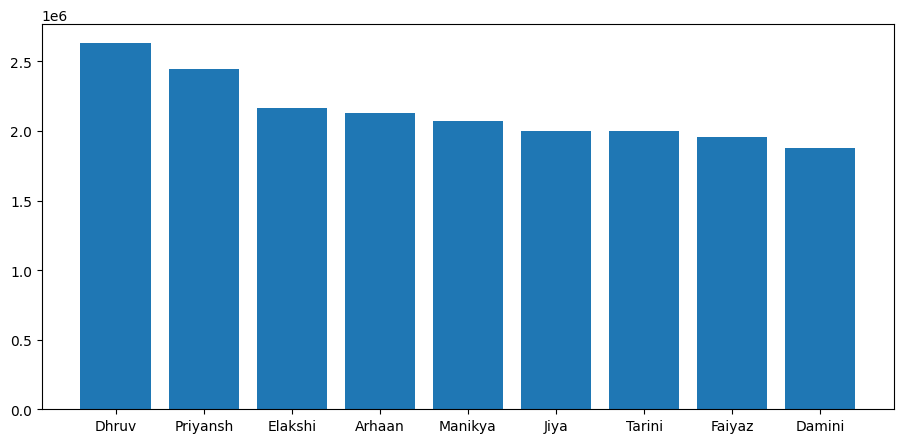

In [61]:
plt.figure(figsize=(11,5))
plt.bar(x = customer , height= expend)